In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

from pathlib import Path
#define project root as the parent directory for absolute file paths
PROJECT_ROOT = Path.cwd().parents[0] #this is relative to this notebook
sys.path.insert(0, str(PROJECT_ROOT))
#define directory paths here!
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "trained_models"
PLOT_DIR = PROJECT_ROOT / "plots"
RESULTS_DIR = PROJECT_ROOT / "results"
SRC_DIR = PROJECT_ROOT / "src"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
METABOLIC_MODELS_DIR = PROJECT_ROOT / "model"

In [3]:
import numpy as np
import cobra
from cobra.io import load_model, read_sbml_model
import matplotlib.pyplot as plt
import src.FBA_data_generation
import src.plotting


2


In [4]:
model_path = PROJECT_ROOT / "model" / "ECC2comp_configured"
model = read_sbml_model(model_path)
vman = "ACKr"
file_path = f"data/fba_data_{vman}_aerobic.npz"

In [ ]:
from scripts.generate_fba_data import configure_medium
medium = configure_medium(model, condition="anerobic", objective="EX_Biomass")

medium = model.medium
medium['EX_o2_e'] = 0.0
model.medium = medium


X, Y, feasible_range = src.FBA_data_generation.generate_fba_data(model=model, vman=vman, file_path=file_path, n_samples=1000)



Objective value: 0.2885897001304516
ACKr value: 7.666402215139818
glycine uptake: 0.0
{'EX_Biomass': 1000.0, 'EX_4CRSOL_e': 1000.0, 'EX_5DRIB_e': 1000.0, 'EX_ac_e': 1000.0, 'EX_adp_c': 1000.0, 'EX_AMOB_e': 1000.0, 'EX_ca2_e': 1000.0, 'EX_cl_e': 1000.0, 'EX_co2_e': 1000.0, 'EX_coa_c': 1000.0, 'EX_cobalt2_e': 1000.0, 'EX_cu2_e': 1000.0, 'EX_etoh_e': 1000.0, 'EX_fe2_e': 1000.0, 'EX_fe3_e': 1000.0, 'EX_for_e': 1000.0, 'EX_glc__D_e': 10.0, 'EX_h_e': 1000.0, 'EX_h2_e': 1000.0, 'EX_h2o_e': 1000.0, 'EX_k_e': 1000.0, 'EX_lac_e': 1000.0, 'EX_meoh_e': 1000.0, 'EX_mg2_e': 1000.0, 'EX_mn2_e': 1000.0, 'EX_mobd_e': 1000.0, 'EX_mqn8_c': 1000.0, 'EX_MTHTHF_e': 1000.0, 'EX_nad_c': 1000.0, 'EX_nadp_c': 1000.0, 'EX_nh4_e': 1000.0, 'EX_ni2_e': 1000.0, 'EX_pi_c': 1000.0, 'EX_pi_e': 1000.0, 'EX_q8_c': 1000.0, 'EX_so4_e': 1000.0, 'EX_zn2_e': 1000.0}
reaction bounds: [-1000.0, 1000.0]
MODEL OBJECTIVE: Maximize
1.0*EX_Biomass - 1.0*EX_Biomass_reverse_4270f


/home/jkaatz/MA/MLDynamicMetabolicControl/.venv/lib64/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Feasibility sweep completed.
Feasible region for ACKr: [-14.66, 9.95]


In [6]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from src.surrogateNN import SurrogateNN
from src.flux_config import FLUX_LABELS

In [7]:


model_nn = SurrogateNN(input_dim=1, hidden_dim=4, output_dim=4)
model_path = MODEL_DIR / "ACKr_EX_Biomass_trained_model_input-1_output-4_hidden-4.pt"
from src.runtime_utils import load_surrogate_checkpoint  # noqa: E402

model, x_scaler, y_scaler, metadata = load_surrogate_checkpoint(model_path, SurrogateNN)




model_nn.eval()


Initializing SurrogateNN with input_dim=1, hidden_dim=4, output_dim=4
Initializing SurrogateNN with input_dim=1, hidden_dim=4, output_dim=7


SurrogateNN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
  )
)

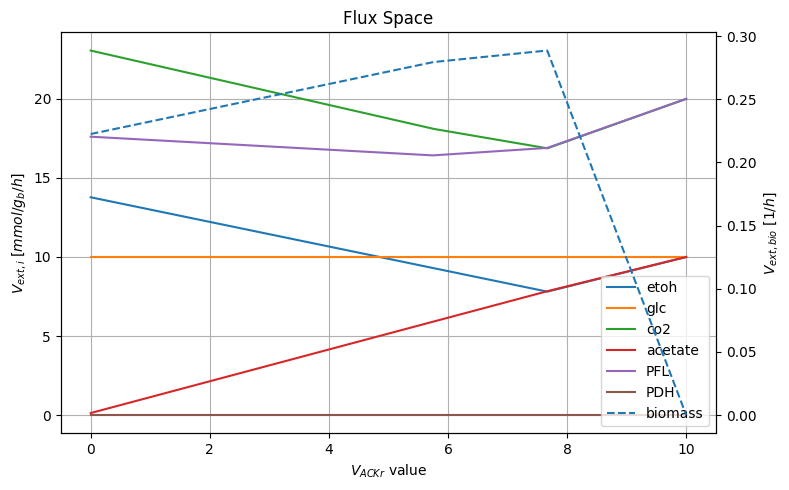

In [8]:
import src.plotting
from src.plotting  import plot_flux_space

plot_flux_space(X, Y, [0,10], "ACKr")


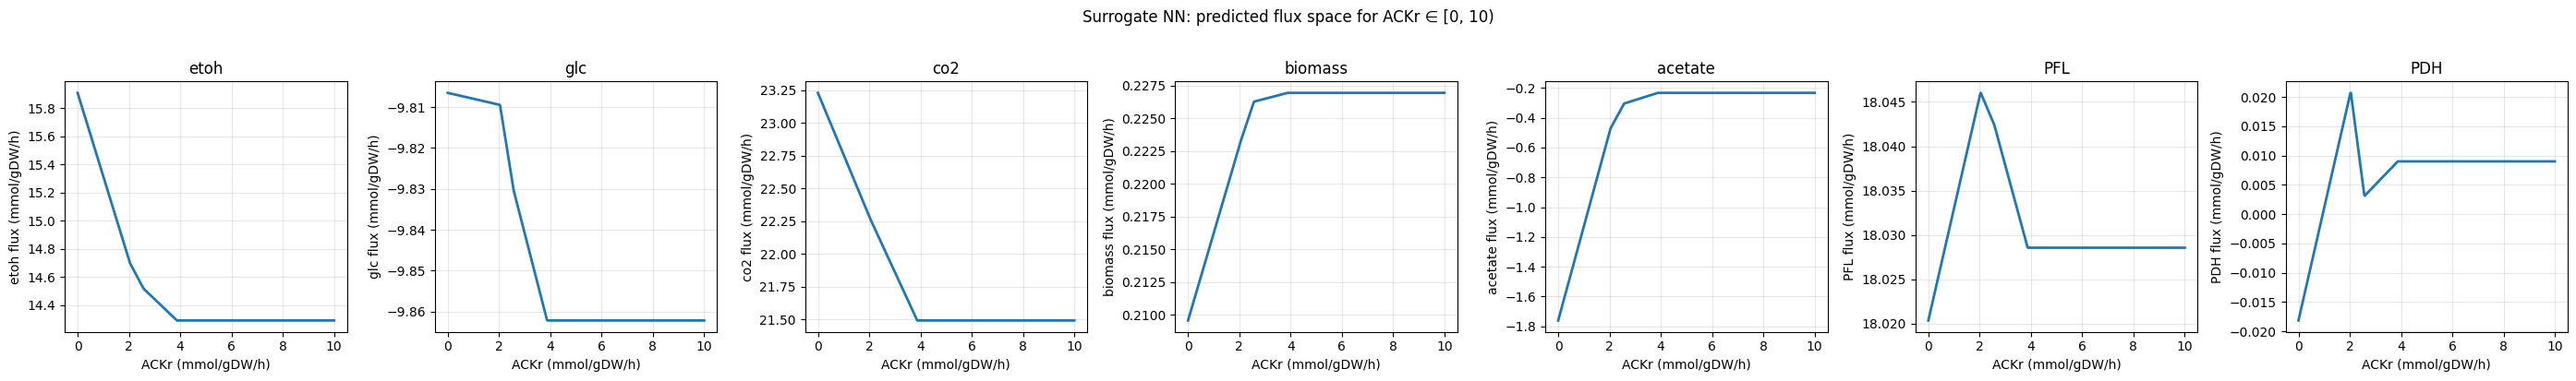

In [9]:
# Sweep ACKr control input over [0, 10) and plot predicted flux space
vman_sweep = np.linspace(0, 10, 500).reshape(-1, 1)

# Scale input, run model, inverse-transform output
vman_scaled = x_scaler.transform(vman_sweep)
with torch.no_grad():
    y_scaled = model(torch.tensor(vman_scaled, dtype=torch.float32)).numpy()
y_pred = y_scaler.inverse_transform(y_scaled)

# Plot each output flux vs control input
n_outputs = len(FLUX_LABELS)
fig, axes = plt.subplots(1, n_outputs, figsize=(4 * n_outputs, 4), sharey=False)
if n_outputs == 1:
    axes = [axes]

for i, (ax, label) in enumerate(zip(axes, FLUX_LABELS)):
    ax.plot(vman_sweep, y_pred[:, i], lw=2)
    ax.set_xlabel("ACKr (mmol/gDW/h)")
    ax.set_ylabel(f"{label} flux (mmol/gDW/h)")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

fig.suptitle("Surrogate NN: predicted flux space for ACKr ∈ [0, 10)", y=1.02)
plt.tight_layout()
plt.show()

## Train Surrogate NN

Train a small surrogate neural network on FBA data. Mirrors `scripts/train_surrogate.py`.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

from src.surrogateNN import SurrogateNN, ML_data_prep, train_model
from src.runtime_utils import save_surrogate_checkpoint
from scripts.generate_fba_data import configure_medium
import src.FBA_data_generation

# --- Config ---
VMAN        = "ACKr"
CONDITION   = "anaerobic"
HIDDEN_DIM  = 4
EPOCHS      = 5000
PATIENCE    = 50
LR          = 1e-3
TEST_SIZE   = 0.2
VAL_SIZE    = 0.2
N_SAMPLES   = 1000

# Set up model and medium, then generate FBA data
fba_model = read_sbml_model(str(PROJECT_ROOT / "model" / "ECC2comp_configured"))
configure_medium(fba_model, condition=CONDITION, objective="EX_Biomass")

X_raw, Y_raw, feasible_range = src.FBA_data_generation.generate_fba_data(
    model=fba_model,
    vman=VMAN,
    n_samples=N_SAMPLES,
)
print(f"X shape: {np.array(X_raw).shape}, Y shape: {np.array(Y_raw).shape}")
print(f"Feasible range for {VMAN}: {feasible_range}")

In [ ]:
# Prepare data: scale + train/val/test split
x_scaler, y_scaler, X_train, Y_train, X_val, Y_val, X_test, Y_test = ML_data_prep(
    X_raw, Y_raw, test_size=TEST_SIZE, val_size=VAL_SIZE
)
print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

In [ ]:
# Build and train model
surrogate = SurrogateNN(
    input_dim=X_train.shape[1],
    output_dim=Y_train.shape[1],
    hidden_dim=HIDDEN_DIM,
)

surrogate, train_losses, val_losses = train_model(
    surrogate,
    X_train, Y_train,
    X_val,   Y_val,
    loss_fn=nn.MSELoss(),
    lr=LR,
    epochs=EPOCHS,
    patience=PATIENCE,
    verbose=True,
)

In [ ]:
# Evaluate on test set
surrogate.eval()
with torch.no_grad():
    pred_test = surrogate(X_test)
    test_mse = nn.MSELoss()(pred_test, Y_test).item()

Y_test_true  = y_scaler.inverse_transform(Y_test.numpy())
pred_test_true = y_scaler.inverse_transform(pred_test.numpy())
r2 = r2_score(Y_test_true.flatten(), pred_test_true.flatten())

print(f"Test MSE (scaled): {test_mse:.4f}")
print(f"R² (unscaled):     {r2:.4f}")

# Plot training curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label="Train loss")
ax.plot(val_losses,   label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title(f"Training curves — {VMAN} surrogate (hidden={HIDDEN_DIM})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import src.plotting
from src.plotting import plot_flux_space

# Sweep vman over [0, 10] using the trained surrogate
vman_sweep = np.linspace(0, 10, 500).reshape(-1, 1)

vman_scaled = x_scaler.transform(vman_sweep)
surrogate.eval()
with torch.no_grad():
    y_scaled = surrogate(torch.tensor(vman_scaled, dtype=torch.float32)).numpy()

Y_pred = y_scaler.inverse_transform(y_scaled)

plot_flux_space(vman_sweep.tolist(), Y_pred.tolist(), [0, 10], VMAN)

In [ ]:
# (Optional) Save checkpoint
base_name = f"{VMAN}_{CONDITION}_input-{X_train.shape[1]}_output-{Y_train.shape[1]}_hidden-{HIDDEN_DIM}"
checkpoint_path = MODEL_DIR / f"{base_name}.pt"

metadata = {
    "vman": VMAN,
    "condition": CONDITION,
    "feasible_range": list(feasible_range),
    "hidden_dim": HIDDEN_DIM,
    "epochs": EPOCHS,
    "patience": PATIENCE,
    "lr": LR,
}
save_surrogate_checkpoint(surrogate, x_scaler, y_scaler, metadata, checkpoint_path)
print(f"Saved checkpoint to {checkpoint_path}")

## Hybrid Model Simulation

Simulate biomass and ethanol dynamics over a batch window of 18 h using the trained surrogate inside the hybrid ODE.

In [ ]:
from scipy.integrate import solve_ivp
from src.hybrid_model import hybrid_ode

# --- Simulation config ---
T_START  = 0.0
T_END    = 14.0
T_EVAL   = np.linspace(T_START, T_END, 500)

# Initial conditions [glucose, ethanol, biomass]  (g/L or mmol/L – match your model units)
z0 = [100.0, 0.0, 0.1]

# Control input: VMAN_CONST until T_SWITCH, then 0
VMAN_CONST = 7.66
T_SWITCH   = 7.0
vman_func  = lambda t: VMAN_CONST if t < T_SWITCH else 0.0

# Integrate
sol = solve_ivp(
    fun=lambda t, z: hybrid_ode(t, z, vman_func, surrogate, x_scaler, y_scaler),
    t_span=(T_START, T_END),
    y0=z0,
    t_eval=T_EVAL,
    method="RK45",
    max_step=0.05,
)

if not sol.success:
    print(f"Solver warning: {sol.message}")

glucose, ethanol, biomass = sol.y

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)

axes[0].plot(sol.t, glucose,  color="tab:blue")
axes[0].set_ylabel("Glucose (mmol/L)")
axes[0].set_title("Glucose")

axes[1].plot(sol.t, ethanol,  color="tab:orange")
axes[1].set_ylabel("Ethanol (mmol/L)")
axes[1].set_title("Ethanol")

axes[2].plot(sol.t, biomass,  color="tab:green")
axes[2].set_ylabel("Biomass (g/L)")
axes[2].set_title("Biomass")

for ax in axes:
    ax.set_xlabel("Time (h)")
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Hybrid model simulation — {VMAN}={VMAN_CONST}, t ∈ [0, 18] h")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.integrate import solve_ivp
from src.hybrid_model import hybrid_ode

# --- Search config ---
T_SWITCH_VALUES = np.linspace(0.5, T_END - 0.5, 40)

best_switch   = None
best_ethanol  = -np.inf
results       = {}   # T_SWITCH -> sol

for t_sw in T_SWITCH_VALUES:
    vman_f = lambda t, _t_sw=t_sw: VMAN_CONST if t < _t_sw else 0.0

    sol_i = solve_ivp(
        fun=lambda t, z: hybrid_ode(t, z, vman_f, surrogate, x_scaler, y_scaler),
        t_span=(T_START, T_END),
        y0=z0,
        t_eval=T_EVAL,
        method="RK45",
        max_step=0.05,
    )

    final_ethanol = sol_i.y[1, -1]   # ethanol concentration at T_END
    results[t_sw] = (sol_i, final_ethanol)

    if final_ethanol > best_ethanol:
        best_ethanol = final_ethanol
        best_switch  = t_sw

print(f"Best T_SWITCH: {best_switch:.2f} h  →  final ethanol = {best_ethanol:.4f}")

In [ ]:
best_sol, _ = results[best_switch]
b_glucose, b_ethanol, b_biomass = best_sol.y

# --- Top panel: all ethanol curves (grey) + best (orange) ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
ax_sweep, ax_score = axes[0, 0], axes[0, 1]

for t_sw, (s, _) in results.items():
    ax_sweep.plot(s.t, s.y[1], color="grey", alpha=0.25, lw=0.8)
ax_sweep.plot(best_sol.t, b_ethanol, color="tab:orange", lw=2, label=f"T_switch={best_switch:.2f} h")
ax_sweep.axvline(best_switch, color="tab:orange", ls="--", lw=1)
ax_sweep.set_xlabel("Time (h)")
ax_sweep.set_ylabel("Ethanol (mmol/L)")
ax_sweep.set_title("All simulations — ethanol")
ax_sweep.legend(fontsize=8)
ax_sweep.grid(True, alpha=0.3)

# --- Top-right: final ethanol vs T_SWITCH ---
t_sws    = sorted(results.keys())
finals   = [results[t][1] for t in t_sws]
ax_score.plot(t_sws, finals, marker="o", ms=4, color="tab:blue")
ax_score.axvline(best_switch, color="tab:orange", ls="--", lw=1, label=f"best={best_switch:.2f} h")
ax_score.set_xlabel("T_SWITCH (h)")
ax_score.set_ylabel("Final ethanol (mmol/L)")
ax_score.set_title("Ethanol yield vs switch time")
ax_score.legend(fontsize=8)
ax_score.grid(True, alpha=0.3)

# --- Hide unused top-right subplot ---
axes[0, 2].set_visible(False)

# --- Bottom row: best simulation in detail ---
labels  = ["Glucose (mmol/L)", "Ethanol (mmol/L)", "Biomass (g/L)"]
colors  = ["tab:blue", "tab:orange", "tab:green"]
for ax, data, label, color in zip(axes[1], best_sol.y, labels, colors):
    ax.plot(best_sol.t, data, color=color, lw=2)
    ax.axvline(best_switch, color="grey", ls="--", lw=1, label=f"T_switch={best_switch:.2f} h")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(label)
    ax.set_title(f"Best run — {label.split()[0]}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"T_SWITCH sweep — best final ethanol at t={best_switch:.2f} h ({best_ethanol:.3f} mmol/L)", fontsize=12)
plt.tight_layout()
plt.show()

## Exponential-decay + switch optimisation

Control profile: `vman(t) = V0 · exp(−decay · t)` for `t < T_SWITCH`, else `0`.  
Grid-search over `(T_SWITCH, decay)` to maximise final ethanol.

In [ ]:
from scipy.integrate import solve_ivp
from src.hybrid_model import hybrid_ode

V0 = VMAN_CONST  # 7.66 — fixed initial value

def exp_switch(t, t_switch, decay):
    """Exponential decay until t_switch, then 0."""
    return V0 * np.exp(-decay * t) if t < t_switch else 0.0

def simulate_exp_switch(t_switch, decay):
    vman_f = lambda t: exp_switch(t, t_switch, decay)
    sol = solve_ivp(
        fun=lambda t, z: hybrid_ode(t, z, vman_f, surrogate, x_scaler, y_scaler),
        t_span=(T_START, T_END),
        y0=z0,
        t_eval=T_EVAL,
        method="RK45",
        max_step=0.05,
    )
    return sol

# --- Grid search ---
# decay range anchored around the paper value:
#   7.66 · exp(-decay · 6.6) ≈ 6.2  →  decay ≈ 0.032
N_SWITCH = 25
N_DECAY  = 25
t_switch_grid = np.linspace(1.0, T_END - 0.5, N_SWITCH)
decay_grid    = np.linspace(0.005, 0.15, N_DECAY)

ethanol_map = np.full((N_DECAY, N_SWITCH), np.nan)

for i, decay in enumerate(decay_grid):
    for j, t_sw in enumerate(t_switch_grid):
        sol_ij = simulate_exp_switch(t_sw, decay)
        if sol_ij.success:
            ethanol_map[i, j] = sol_ij.y[1, -1]

# Best parameters
best_idx   = np.unravel_index(np.nanargmax(ethanol_map), ethanol_map.shape)
best_decay = decay_grid[best_idx[0]]
best_tswitch = t_switch_grid[best_idx[1]]
best_val   = ethanol_map[best_idx]

print(f"Best T_SWITCH : {best_tswitch:.3f} h")
print(f"Best decay    : {best_decay:.4f}  (V0·exp(-decay·T_SWITCH) = {V0*np.exp(-best_decay*best_tswitch):.3f})")
print(f"Final ethanol : {best_val:.4f} mmol/L")

In [ ]:
best_sol = simulate_exp_switch(best_tswitch, best_decay)
t_plot   = np.linspace(T_START, T_END, 500)
vman_profile = np.array([exp_switch(t, best_tswitch, best_decay) for t in t_plot])

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# --- Heatmap of final ethanol over parameter grid ---
ax_map = axes[0, 0]
im = ax_map.contourf(t_switch_grid, decay_grid, ethanol_map, levels=30, cmap="viridis")
fig.colorbar(im, ax=ax_map, label="Final ethanol (mmol/L)")
ax_map.scatter([best_tswitch], [best_decay], color="red", zorder=5, s=80, label="best")
ax_map.set_xlabel("T_SWITCH (h)")
ax_map.set_ylabel("Decay rate")
ax_map.set_title("Objective landscape")
ax_map.legend(fontsize=8)

# --- Best control profile ---
ax_ctrl = axes[0, 1]
ax_ctrl.plot(t_plot, vman_profile, color="tab:purple", lw=2)
ax_ctrl.axvline(best_tswitch, color="grey", ls="--", lw=1, label=f"T_switch={best_tswitch:.2f} h")
ax_ctrl.set_xlabel("Time (h)")
ax_ctrl.set_ylabel("vman (mmol/gDW/h)")
ax_ctrl.set_title(f"Best control profile  (decay={best_decay:.4f})")
ax_ctrl.legend(fontsize=8)
ax_ctrl.grid(True, alpha=0.3)

# --- Best simulation: ethanol & biomass ---
for ax, (row, label, color) in zip(axes[1], [
        (1, "Ethanol (mmol/L)", "tab:orange"),
        (2, "Biomass (g/L)",    "tab:green"),
]):
    ax.plot(best_sol.t, best_sol.y[row], color=color, lw=2)
    ax.axvline(best_tswitch, color="grey", ls="--", lw=1, label=f"T_switch={best_tswitch:.2f} h")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(label)
    ax.set_title(f"Best run — {label.split()[0]}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Exp-decay + switch optimisation\n"
    f"T_switch={best_tswitch:.2f} h, decay={best_decay:.4f}, "
    f"vman(T_switch)={V0*np.exp(-best_decay*best_tswitch):.2f} → 0",
    fontsize=11,
)
plt.tight_layout()
plt.show()